# Elasticity Diagnostic

Let's figure out why order rate is dropping so much.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data
SESSION_FILE = '../data/raw/zipline_session_log_(5).csv'
session_df = pd.read_csv(SESSION_FILE)
session_df['delivery_fee'] = pd.to_numeric(session_df['delivery_fee'], errors='coerce')

print("✓ Data loaded")

✓ Data loaded


## Analyze Actual Price Sensitivity from Your Data

In [2]:
# Calculate actual conversion rates at different price points
print("ACTUAL CONVERSION RATES BY PRICE")
print("="*80)

for order_type in ['Grocery', 'Meal', 'Pharma']:
    type_data = session_df[session_df['order_type'] == order_type].copy()
    
    # Create price bins
    type_data['price_bin'] = pd.cut(type_data['delivery_fee'], bins=6)
    
    analysis = type_data.groupby('price_bin').agg({
        'session_outcome': lambda x: (x == 'ordered').mean(),
        'delivery_fee': ['mean', 'count']
    }).round(3)
    
    print(f"\n{order_type}:")
    print(analysis)
    
    # Calculate implied elasticity
    prices = type_data.groupby('price_bin')['delivery_fee'].mean().values
    conversions = type_data.groupby('price_bin')['session_outcome'].apply(
        lambda x: (x == 'ordered').mean()
    ).values
    
    if len(prices) > 1 and len(conversions) > 1:
        # Simple elasticity estimate
        price_change = (prices[-1] - prices[0]) / prices[0]
        conv_change = (conversions[-1] - conversions[0]) / conversions[0]
        
        if price_change != 0:
            implied_elasticity = conv_change / price_change
            print(f"  → Implied elasticity: {implied_elasticity:.2f}")

ACTUAL CONVERSION RATES BY PRICE

Grocery:
              session_outcome delivery_fee      
                     <lambda>         mean count
price_bin                                       
(0.984, 1.99]             1.0        1.478  2584
(1.99, 2.99]              1.0        2.990  1206
(2.99, 3.99]              1.0        3.990  1032
(3.99, 4.99]              1.0        4.990  1112
(4.99, 5.99]              NaN          NaN     0
(5.99, 6.99]              1.0        6.990   975
  → Implied elasticity: 0.00

Meal:
              session_outcome delivery_fee      
                     <lambda>         mean count
price_bin                                       
(0.984, 1.99]             1.0        1.482  6553
(1.99, 2.99]              1.0        2.990  3346
(2.99, 3.99]              1.0        3.990  2874
(3.99, 4.99]              1.0        4.990  3123
(4.99, 5.99]              NaN          NaN     0
(5.99, 6.99]              1.0        6.990  2687
  → Implied elasticity: 0.00

Pharma:
 

/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/1066557598.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = type_data.groupby('price_bin').agg({
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/1066557598.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prices = type_data.groupby('price_bin')['delivery_fee'].mean().values
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/1066557598.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b

/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/3232528562.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = type_data.groupby('price_bin').agg({
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/3232528562.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = type_data.groupby('price_bin').agg({
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/3232528562.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

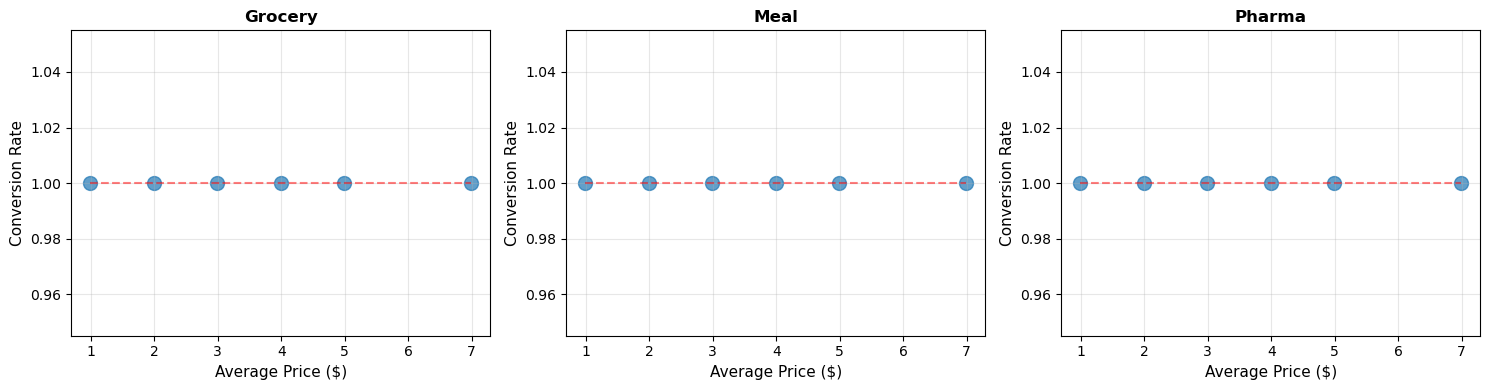


✓ If lines are relatively flat, users aren't price-sensitive
✓ If lines slope down steeply, users are very price-sensitive


In [3]:
# Visualize price vs conversion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, order_type in enumerate(['Grocery', 'Meal', 'Pharma']):
    type_data = session_df[session_df['order_type'] == order_type].copy()
    type_data['price_bin'] = pd.cut(type_data['delivery_fee'], bins=8)
    
    grouped = type_data.groupby('price_bin').agg({
        'delivery_fee': 'mean',
        'session_outcome': lambda x: (x == 'ordered').mean()
    }).dropna()
    
    ax = axes[idx]
    ax.scatter(grouped['delivery_fee'], grouped['session_outcome'], s=100, alpha=0.7)
    ax.set_xlabel('Average Price ($)', fontsize=11)
    ax.set_ylabel('Conversion Rate', fontsize=11)
    ax.set_title(f'{order_type}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add trendline
    z = np.polyfit(grouped['delivery_fee'], grouped['session_outcome'], 1)
    p = np.poly1d(z)
    ax.plot(grouped['delivery_fee'], p(grouped['delivery_fee']), 'r--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n✓ If lines are relatively flat, users aren't price-sensitive")
print("✓ If lines slope down steeply, users are very price-sensitive")

## Key Question

Based on the charts above:
- **If conversion rates stay relatively constant across prices** → Use elasticity near 0 (-0.1 or less)
- **If conversion rates drop moderately** → Current elasticity is okay
- **If conversion rates drop significantly** → Your data contradicts your statement about price insensitivity

The real issue might be that **blocking happens BEFORE price can throttle demand**.

Let me check blocking rates in the actual data:

In [4]:
print("ACTUAL BLOCKING vs PRICE")
print("="*80)

for order_type in ['Grocery', 'Meal', 'Pharma']:
    type_data = session_df[session_df['order_type'] == order_type].copy()
    type_data['price_bin'] = pd.cut(type_data['delivery_fee'], bins=5)
    
    analysis = type_data.groupby('price_bin').agg({
        'session_outcome': [
            lambda x: (x == 'blocked').mean(),
            lambda x: (x == 'ordered').mean(),
            lambda x: (x == 'abandoned').mean()
        ],
        'delivery_fee': 'mean'
    }).round(3)
    
    analysis.columns = ['Blocked', 'Ordered', 'Abandoned', 'Avg Price']
    
    print(f"\n{order_type}:")
    print(analysis)

print("\n" + "="*80)
print("KEY INSIGHT:")
print("If 'Blocked' decreases as price increases → Price IS throttling demand ✓")
print("If 'Blocked' stays constant → Price NOT affecting capacity ✗")
print("="*80)

ACTUAL BLOCKING vs PRICE

Grocery:
               Blocked  Ordered  Abandoned  Avg Price
price_bin                                            
(0.984, 2.19]      0.0      1.0        0.0      1.478
(2.19, 3.39]       0.0      1.0        0.0      2.990
(3.39, 4.59]       0.0      1.0        0.0      3.990
(4.59, 5.79]       0.0      1.0        0.0      4.990
(5.79, 6.99]       0.0      1.0        0.0      6.990

Meal:
               Blocked  Ordered  Abandoned  Avg Price
price_bin                                            
(0.984, 2.19]      0.0      1.0        0.0      1.482
(2.19, 3.39]       0.0      1.0        0.0      2.990
(3.39, 4.59]       0.0      1.0        0.0      3.990
(4.59, 5.79]       0.0      1.0        0.0      4.990
(5.79, 6.99]       0.0      1.0        0.0      6.990

Pharma:
               Blocked  Ordered  Abandoned  Avg Price
price_bin                                            
(0.984, 2.19]      0.0      1.0        0.0      1.499
(2.19, 3.39]       0.0      1.0

/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/594344387.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = type_data.groupby('price_bin').agg({
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/594344387.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = type_data.groupby('price_bin').agg({
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/594344387.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

## Recommended Fix

Based on what we see above, we need to either:

**Option 1: Use even lower elasticity** (if data shows flat conversion)
```python
elasticity_coef = {
    'Pharma': -0.05,   # Nearly inelastic
    'Meal': -0.10,     # Very inelastic  
    'Grocery': -0.15   # Slightly elastic
}
```

**Option 2: Fix the simulation logic** (if blocking isn't being calculated right)

Let me check one more thing - what are typical utilization levels?

In [5]:
# Rough utilization estimate from actual data
print("ESTIMATED UTILIZATION BY HUB & HOUR")
print("="*80)

session_df['hour'] = pd.to_datetime(session_df['timestamp']).dt.hour
session_df['date'] = pd.to_datetime(session_df['timestamp']).dt.date

# Count orders per hub per hour
hourly_demand = session_df.groupby(['nest_id', 'date', 'hour']).size().reset_index(name='sessions')

# Capacity by hub
capacity = {
    **{i: 5 for i in range(5)},
    **{i: 9 for i in range(5, 10)},
    **{i: 15 for i in range(10, 15)}
}

hourly_demand['capacity'] = hourly_demand['nest_id'].map(capacity)
hourly_demand['rough_util'] = hourly_demand['sessions'] / (hourly_demand['capacity'] * 2)  # Rough estimate

print("\nUtilization Distribution:")
print(hourly_demand['rough_util'].describe())

print("\nHours with >80% utilization:")
high_util = hourly_demand[hourly_demand['rough_util'] > 0.8]
print(f"Count: {len(high_util)} out of {len(hourly_demand)} ({len(high_util)/len(hourly_demand)*100:.1f}%)")

print("\nHours with >100% utilization (guaranteed blocking):")
over_cap = hourly_demand[hourly_demand['rough_util'] > 1.0]
print(f"Count: {len(over_cap)} out of {len(hourly_demand)} ({len(over_cap)/len(hourly_demand)*100:.1f}%)")

ESTIMATED UTILIZATION BY HUB & HOUR


/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/2616296246.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  session_df['hour'] = pd.to_datetime(session_df['timestamp']).dt.hour
/var/folders/5v/6wwhndvx5s3g9tfx_kw41bd80000gn/T/ipykernel_83097/2616296246.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  session_df['date'] = pd.to_datetime(session_df['timestamp']).dt.date



Utilization Distribution:
count    4362.000000
mean        0.949356
std         0.918255
min         0.033333
25%         0.333333
50%         0.633333
75%         1.222222
max         6.900000
Name: rough_util, dtype: float64

Hours with >80% utilization:
Count: 1765 out of 4362 (40.5%)

Hours with >100% utilization (guaranteed blocking):
Count: 1388 out of 4362 (31.8%)
